# Stack Overflow Survey Cleaning (2015-2025)

This notebook takes the main EDA findings and turns them into a first cleaning pass focused on respondent overviews, cross-year change, regional analysis, and a compensation-ready sample.

## Plan

- rebuild the cross-year respondent table
- make cohort denominators explicit
- clean the highest-friction fields from EDA
- leave a respondent-level `clean_core` table ready for later analysis and modeling

In [8]:
import logging
import re
import warnings
from pathlib import Path

import country_converter as coco
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='FigureCanvasAgg is non-interactive')
logging.getLogger('country_converter').setLevel(logging.ERROR)
logging.getLogger('country_converter.country_converter').setLevel(logging.ERROR)

# Set display defaults for pandas, seaborn, and matplotlib
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 150)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120


def find_root():
    here = Path.cwd()
    for path in [here, *here.parents]:
        if (path / 'data').exists():
            return path
    raise FileNotFoundError("Could not find project root")


ROOT = find_root()
DATA_DIR = ROOT / 'data'

print(ROOT)


c:\Users\davis\Documents\VCCode Repos\Stack-Overflow-Survey-Analysis\DSBA-6211-Stack-overflow-Survey-Analysis


In [2]:
YEAR_INFO = {
    2015: {
        'file': '2015 Stack Overflow Developer Survey Responses.csv',
        'header': 1,
        'response_id': None,
        'country': 'Country',
        'age': 'Age',
        'gender': 'Gender',
        'main_branch': None,
        'student': None,
        'employment': 'Employment Status',
        'education': None,
        'org_size': None,
        'dev_type': 'Occupation',
        'industry': 'Industry',
        'remote': 'Remote Status',
        'years_code': 'Years IT / Programming Experience',
        'years_code_pro': None,
        'work_exp': None,
        'comp': 'Compensation: midpoint',
        'job_sat': 'Job Satisfaction',
        'career_sat': None,
        'language': None,
        'database': None,
        'platform': None,
        'ai_use': None,
        'ai_sent': None
    },
    2016: {
        'file': '2016 Stack Overflow Survey Responses.csv',
        'header': 0,
        'response_id': None,
        'country': 'country',
        'age': 'age_midpoint',
        'gender': 'gender',
        'main_branch': None,
        'student': None,
        'employment': 'employment_status',
        'education': 'education',
        'org_size': 'company_size_range',
        'dev_type': 'occupation',
        'industry': 'industry',
        'remote': 'remote',
        'years_code': 'experience_range',
        'years_code_pro': 'experience_range',
        'work_exp': None,
        'comp': 'salary_midpoint',
        'job_sat': None,
        'career_sat': None,
        'language': None,
        'database': None,
        'platform': None,
        'ai_use': None,
        'ai_sent': None
    },
    2017: {
        'file': 'survey_results_public2017.csv',
        'header': 0,
        'response_id': 'Respondent',
        'country': 'Country',
        'age': None,
        'gender': None,
        'main_branch': None,
        'student': None,
        'employment': 'EmploymentStatus',
        'education': 'FormalEducation',
        'org_size': 'CompanySize',
        'dev_type': 'DeveloperType',
        'industry': None,
        'remote': 'HomeRemote',
        'years_code': 'YearsProgram',
        'years_code_pro': 'YearsCodedJob',
        'work_exp': None,
        'comp': 'Salary',
        'job_sat': 'JobSatisfaction',
        'career_sat': 'CareerSatisfaction',
        'language': 'HaveWorkedLanguage',
        'database': 'HaveWorkedDatabase',
        'platform': 'HaveWorkedPlatform',
        'ai_use': None,
        'ai_sent': None
    },
    2018: {
        'file': 'survey_results_public2018.csv',
        'header': 0,
        'response_id': 'Respondent',
        'country': 'Country',
        'age': 'Age',
        'gender': 'Gender',
        'main_branch': None,
        'student': 'Student',
        'employment': 'Employment',
        'education': 'FormalEducation',
        'org_size': 'CompanySize',
        'dev_type': 'DevType',
        'industry': None,
        'remote': None,
        'years_code': 'YearsCoding',
        'years_code_pro': 'YearsCodingProf',
        'work_exp': None,
        'comp': 'ConvertedSalary',
        'job_sat': 'JobSatisfaction',
        'career_sat': 'CareerSatisfaction',
        'language': 'LanguageWorkedWith',
        'database': 'DatabaseWorkedWith',
        'platform': 'PlatformWorkedWith',
        'ai_use': None,
        'ai_sent': None
    },
    2019: {
        'file': 'survey_results_public2019.csv',
        'header': 0,
        'response_id': 'Respondent',
        'country': 'Country',
        'age': 'Age',
        'gender': 'Gender',
        'main_branch': 'MainBranch',
        'student': 'Student',
        'employment': 'Employment',
        'education': 'EdLevel',
        'org_size': 'OrgSize',
        'dev_type': 'DevType',
        'industry': None,
        'remote': 'WorkRemote',
        'years_code': 'YearsCode',
        'years_code_pro': 'YearsCodePro',
        'work_exp': None,
        'comp': 'ConvertedComp',
        'job_sat': 'JobSat',
        'career_sat': 'CareerSat',
        'language': 'LanguageWorkedWith',
        'database': 'DatabaseWorkedWith',
        'platform': 'PlatformWorkedWith',
        'ai_use': None,
        'ai_sent': None
    },
    2020: {
        'file': 'survey_results_2020.csv',
        'header': 0,
        'response_id': 'Respondent',
        'country': 'Country',
        'age': 'Age',
        'gender': 'Gender',
        'main_branch': 'MainBranch',
        'student': None,
        'employment': 'Employment',
        'education': 'EdLevel',
        'org_size': 'OrgSize',
        'dev_type': 'DevType',
        'industry': None,
        'remote': None,
        'years_code': 'YearsCode',
        'years_code_pro': 'YearsCodePro',
        'work_exp': None,
        'comp': 'ConvertedComp',
        'job_sat': 'JobSat',
        'career_sat': None,
        'language': 'LanguageWorkedWith',
        'database': 'DatabaseWorkedWith',
        'platform': 'PlatformWorkedWith',
        'ai_use': None,
        'ai_sent': None
    },
    2021: {
        'file': 'survey_results_2021.csv',
        'header': 0,
        'response_id': 'ResponseId',
        'country': 'Country',
        'age': 'Age',
        'gender': 'Gender',
        'main_branch': 'MainBranch',
        'student': None,
        'employment': 'Employment',
        'education': 'EdLevel',
        'org_size': 'OrgSize',
        'dev_type': 'DevType',
        'industry': None,
        'remote': None,
        'years_code': 'YearsCode',
        'years_code_pro': 'YearsCodePro',
        'work_exp': None,
        'comp': 'ConvertedCompYearly',
        'job_sat': None,
        'career_sat': None,
        'language': 'LanguageHaveWorkedWith',
        'database': 'DatabaseHaveWorkedWith',
        'platform': 'PlatformHaveWorkedWith',
        'ai_use': None,
        'ai_sent': None
    },
    2022: {
        'file': 'survey_results_2022.csv',
        'header': 0,
        'response_id': 'ResponseId',
        'country': 'Country',
        'age': 'Age',
        'gender': 'Gender',
        'main_branch': 'MainBranch',
        'student': None,
        'employment': 'Employment',
        'education': 'EdLevel',
        'org_size': 'OrgSize',
        'dev_type': 'DevType',
        'industry': None,
        'remote': 'RemoteWork',
        'years_code': 'YearsCode',
        'years_code_pro': 'YearsCodePro',
        'work_exp': 'WorkExp',
        'comp': 'ConvertedCompYearly',
        'job_sat': None,
        'career_sat': None,
        'language': 'LanguageHaveWorkedWith',
        'database': 'DatabaseHaveWorkedWith',
        'platform': 'PlatformHaveWorkedWith',
        'ai_use': None,
        'ai_sent': None
    },
    2023: {
        'file': 'survey_results_2023.csv',
        'header': 0,
        'response_id': 'ResponseId',
        'country': 'Country',
        'age': 'Age',
        'gender': None,
        'main_branch': 'MainBranch',
        'student': None,
        'employment': 'Employment',
        'education': 'EdLevel',
        'org_size': 'OrgSize',
        'dev_type': 'DevType',
        'industry': 'Industry',
        'remote': 'RemoteWork',
        'years_code': 'YearsCode',
        'years_code_pro': 'YearsCodePro',
        'work_exp': 'WorkExp',
        'comp': 'ConvertedCompYearly',
        'job_sat': None,
        'career_sat': None,
        'language': 'LanguageHaveWorkedWith',
        'database': 'DatabaseHaveWorkedWith',
        'platform': 'PlatformHaveWorkedWith',
        'ai_use': None,
        'ai_sent': 'AISent'
    },
    2024: {
        'file': 'survey_results_2024.csv',
        'header': 0,
        'response_id': 'ResponseId',
        'country': 'Country',
        'age': 'Age',
        'gender': None,
        'main_branch': 'MainBranch',
        'student': None,
        'employment': 'Employment',
        'education': 'EdLevel',
        'org_size': 'OrgSize',
        'dev_type': 'DevType',
        'industry': 'Industry',
        'remote': 'RemoteWork',
        'years_code': 'YearsCode',
        'years_code_pro': 'YearsCodePro',
        'work_exp': 'WorkExp',
        'comp': 'ConvertedCompYearly',
        'job_sat': 'JobSat',
        'career_sat': None,
        'language': 'LanguageHaveWorkedWith',
        'database': 'DatabaseHaveWorkedWith',
        'platform': 'PlatformHaveWorkedWith',
        'ai_use': 'AISelect',
        'ai_sent': 'AISent'
    },
    2025: {
        'file': 'survey_results_2025.csv',
        'header': 0,
        'response_id': 'ResponseId',
        'country': 'Country',
        'age': 'Age',
        'gender': None,
        'main_branch': 'MainBranch',
        'student': None,
        'employment': 'Employment',
        'education': 'EdLevel',
        'org_size': 'OrgSize',
        'dev_type': 'DevType',
        'industry': 'Industry',
        'remote': 'RemoteWork',
        'years_code': 'YearsCode',
        'years_code_pro': None,
        'work_exp': 'WorkExp',
        'comp': 'ConvertedCompYearly',
        'job_sat': 'JobSat',
        'career_sat': None,
        'language': 'LanguageHaveWorkedWith',
        'database': 'DatabaseHaveWorkedWith',
        'platform': 'PlatformHaveWorkedWith',
        'ai_use': 'AISelect',
        'ai_sent': 'AISent'
    }
}

YEARS = sorted(YEAR_INFO)
YEARS

[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

In [3]:
def parse_midpoint(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)

    text = str(value).strip()
    lower = text.lower()
    numbers = [float(x) for x in re.findall(r"\d+(?:\.\d+)?", text.replace(',', ''))]

    if not numbers:
        return np.nan
    if len(numbers) >= 2:
        return sum(numbers[:2]) / 2
    if 'under' in lower or text.startswith('<'):
        return max(numbers[0] - 1, 0)
    return numbers[0]


def read_year(year, columns):
    info = YEAR_INFO[year]
    path = DATA_DIR / info['file']
    return pd.read_csv(
        path,
        header=info['header'],
        usecols=columns,
        low_memory=False
    )


def load_year(year):
    info = YEAR_INFO[year]
    selected = [value for key, value in info.items() if key not in ['file', 'header'] and value is not None]
    df = read_year(year, selected)

    out = pd.DataFrame(index=df.index)
    out['row_id'] = year * 1_000_000 + np.arange(len(df))
    out['survey_year'] = year

    for field in [
        'response_id',
        'country',
        'age',
        'gender',
        'main_branch',
        'student',
        'employment',
        'education',
        'org_size',
        'dev_type',
        'industry',
        'remote',
        'years_code',
        'years_code_pro',
        'work_exp',
        'comp',
        'job_sat',
        'career_sat',
        'language',
        'database',
        'platform',
        'ai_use',
        'ai_sent'
    ]:
        raw_col = info[field]
        out[field] = df[raw_col] if raw_col is not None else pd.NA

    out['age_num'] = out['age'].map(parse_midpoint)
    out['years_code_num'] = out['years_code'].map(parse_midpoint)
    out['years_code_pro_num'] = out['years_code_pro'].map(parse_midpoint)
    out['work_exp_num'] = out['work_exp'].map(parse_midpoint)
    out['comp_usd'] = out['comp'].map(parse_midpoint)
    out['job_sat_num'] = pd.to_numeric(out['job_sat'], errors='coerce')

    return out


core = pd.concat([load_year(year) for year in YEARS], ignore_index=True)
print(core.shape)
display(core.sample(8, random_state=42))


core_raw = core.copy()

(746226, 31)


,row_id,survey_year,response_id,country,age,gender,main_branch,student,employment,education,org_size,dev_type,industry,remote,years_code,years_code_pro,work_exp,comp,job_sat,career_sat,language,database,platform,ai_use,ai_sent,age_num,years_code_num,years_code_pro_num,work_exp_num,comp_usd,job_sat_num
660422,2024028824,2024,28825,Thailand,25-34 years old,NaN,I am a developer by profession,NaN,"Employed, full-time","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",10 to 19 employees,"Developer, full-stack",NaN,In-person,8,1,NaN,NaN,NaN,NaN,C#;HTML/CSS;JavaScript;SQL,MariaDB;MongoDB;MySQL,NaN,Yes,Favorable,29.5,8.0,1.0,NaN,NaN,NaN
115194,2017033078,2017,33079,New Zealand,NaN,NaN,NaN,NaN,"Not employed, and not looking for work",Secondary school,NaN,NaN,NaN,NaN,2 to 3 years,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,NaN
462718,2021077011,2021,77012,Denmark,35-44 years old,Man,I am a developer by profession,NaN,Employed full-time,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",20 to 99 employees,"Developer, desktop or enterprise applications;...",NaN,NaN,30,20,NaN,118104.0,NaN,NaN,Clojure;Haskell;Kotlin,DynamoDB;PostgreSQL;SQLite,AWS;DigitalOcean,NaN,NaN,39.5,30.0,20.0,NaN,118104.0,NaN
683102,2024051504,2024,51505,United States of America,25-34 years old,NaN,I am a developer by profession,NaN,"Employed, full-time","Bachelor’s degree (B.A., B.S., B.Eng., etc.)","5,000 to 9,999 employees","Developer, back-end",Software Development,"Hybrid (some remote, some in-person)",14,6,6.0,NaN,7.0,NaN,Java,MySQL,Amazon Web Services (AWS),"No, and I don't plan to",NaN,29.5,14.0,6.0,6.0,NaN,7.0
116754,2017034638,2017,34639,United States,NaN,NaN,NaN,NaN,Employed full-time,Bachelor's degree,100 to 499 employees,Web developer,NaN,All or almost all the time (I'm full-time remote),14 to 15 years,8 to 9 years,NaN,NaN,6.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,14.5,8.5,NaN,NaN,6.0
533507,2022064361,2022,64362,United States of America,55-64 years old,Man,I am a developer by profession,NaN,"Employed, full-time","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",100 to 499 employees,"Developer, back-end;Other (please specify):",NaN,"Hybrid (some remote, some in-person)",32,28,28.0,116000.0,NaN,NaN,C#;PowerShell;SQL,Microsoft SQL Server,Microsoft Azure,NaN,NaN,59.5,32.0,28.0,28.0,116000.0,NaN
298513,2019066150,2019,66571,United States,21.0,Man,I am a developer by profession,No,Employed full-time,"Bachelor’s degree (BA, BS, B.Eng., etc.)",100 to 499 employees,"Developer, desktop or enterprise applications;...",NaN,Less than once per month / Never,6,1,NaN,51000.0,Very satisfied,Very satisfied,Bash/Shell/PowerShell;C++;HTML/CSS;JavaScript,NaN,Windows,NaN,NaN,21.0,6.0,1.0,NaN,51000.0,NaN
199246,2018065738,2018,93313,Germany,NaN,NaN,NaN,"Yes, full-time",Employed full-time,"Master’s degree (MA, MS, M.Eng., MBA, etc.)",20 to 99 employees,Back-end developer;Desktop or enterprise appli...,NaN,NaN,24-26 years,15-17 years,NaN,NaN,Extremely dissatisfied,Moderately dissatisfied,C;C++;C#;JavaScript;Python;SQL;HTML;CSS;Bash/S...,MongoDB;SQL Server,Android;Linux;Windows Desktop or Server,NaN,NaN,NaN,25.0,16.0,NaN,NaN,NaN


## Cohorts and Coverage

Start by making the analysis populations and field coverage explicit before applying any cleaning rules.

,rows,employed_share,professional_share
survey_year,,,
2015,26086,0.666,0.652
2016,56030,0.748,0.732
2017,51392,0.867,0.867
2018,98855,0.861,0.781
2019,88883,0.871,0.760
2020,64461,0.825,0.752
2021,83439,0.768,0.712
2022,73268,0.796,0.748
2023,89184,0.819,0.775


,country,age_num,main_branch,employment,education,org_size,dev_type,remote,years_code_num,years_code_pro_num,work_exp_num,comp_usd
survey_year,,,,,,,,,,,,
2015,96.9,97.7,0.0,81.7,0.0,0.0,79.9,61.9,95.2,0.0,0.0,57.0
2016,99.1,98.8,0.0,88.5,80.2,71.3,88.4,71.6,88.4,88.4,0.0,74.5
2017,100.0,0.0,0.0,100.0,100.0,75.7,70.3,85.6,96.6,73.7,0.0,25.1
2018,99.6,65.3,0.0,96.4,95.8,72.4,93.2,0.0,94.9,78.8,0.0,48.3
2019,99.9,89.1,99.4,98.1,97.2,80.8,91.5,79.1,98.9,83.6,0.0,62.8
2020,99.4,70.5,99.5,99.1,89.1,68.8,76.6,0.0,89.5,71.9,0.0,53.9
2021,100.0,98.1,100.0,99.9,99.6,72.8,79.7,0.0,97.8,73.4,0.0,56.1
2022,98.0,96.1,100.0,97.9,97.7,69.7,83.7,80.5,97.4,70.7,50.2,52.0
2023,98.6,99.5,100.0,98.6,98.6,72.9,86.2,82.8,98.0,74.2,48.9,53.8


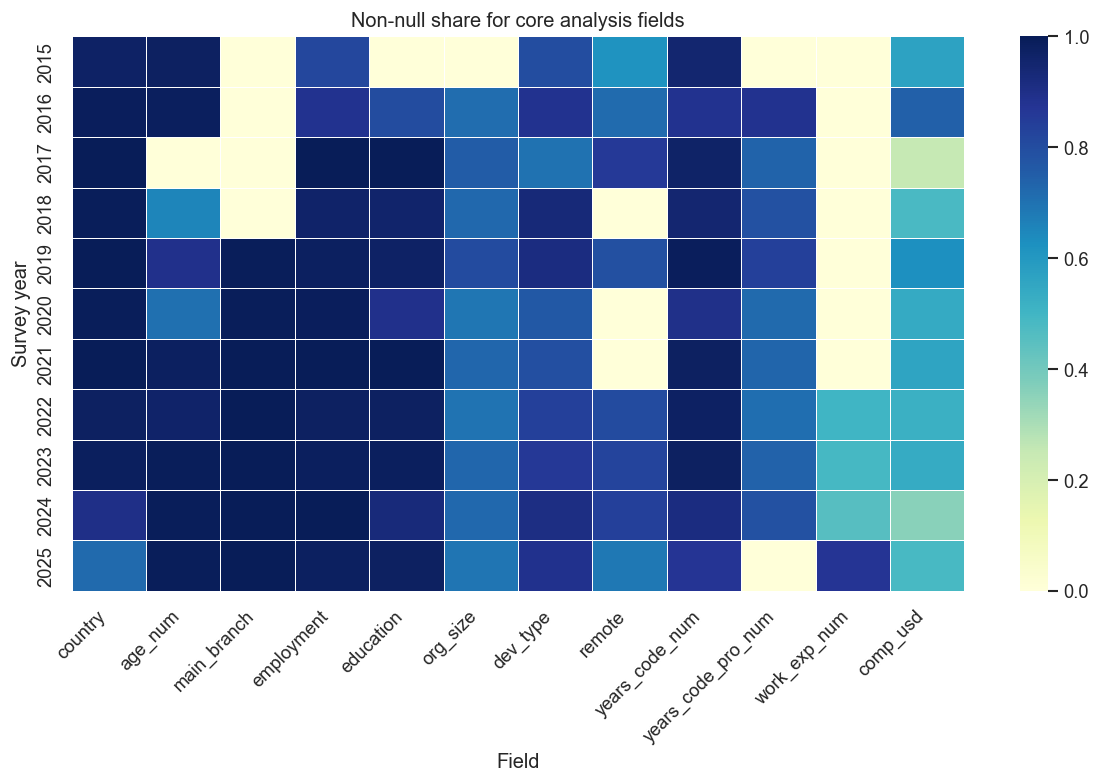

In [4]:
clean = core_raw.copy()


def lower_text(series):
    return series.fillna('').astype(str).str.lower().str.strip()


employment_text = lower_text(clean['employment'])
branch_text = lower_text(clean['main_branch'])
dev_text = lower_text(clean['dev_type'])
student_text = lower_text(clean['student'])

employment_group = np.select(
    [
        employment_text.str.contains('self-employed|independent contractor|freelance|contractor'),
        employment_text.str.contains('part-time') & employment_text.str.contains('employed'),
        employment_text.str.contains('full-time') & employment_text.str.contains('employed'),
        employment_text.str.contains('not employed'),
        student_text.str.contains('yes') | employment_text.str.contains('student')
    ],
    ['Independent / contract', 'Employed part-time', 'Employed full-time', 'Not employed', 'Student'],
    default='Other'
)
clean['employment_group'] = pd.Series(employment_group, index=clean.index).where(clean['employment'].notna() | clean['student'].notna(), pd.NA)

clean['is_employed'] = (
    employment_text.str.contains('employed')
    | employment_text.str.contains('contractor')
    | employment_text.str.contains('freelance')
    | employment_text.str.contains('self-employed')
) & ~employment_text.str.contains('not employed')

clean['is_professional'] = np.where(
    branch_text.ne(''),
    branch_text.str.contains('developer by profession'),
    clean['is_employed'] & ~dev_text.str.contains('student')
)
clean['is_modern_window'] = clean['survey_year'] >= 2019

cohort_summary = clean.groupby('survey_year').agg(rows=('row_id', 'size'), employed_share=('is_employed', 'mean'), professional_share=('is_professional', 'mean'))
display(cohort_summary.round(3))

coverage_fields = ['country', 'age_num', 'main_branch', 'employment', 'education', 'org_size', 'dev_type', 'remote', 'years_code_num', 'years_code_pro_num', 'work_exp_num', 'comp_usd']
coverage = clean.groupby('survey_year')[coverage_fields].apply(lambda frame: frame.notna().mean())
display((coverage * 100).round(1))

plt.figure(figsize=(12, 6))
sns.heatmap(coverage, cmap='YlGnBu', linewidths=0.5)
plt.title("Non-null share for core analysis fields")
plt.xlabel("Field")
plt.ylabel("Survey year")
plt.xticks(rotation=45, ha='right')
plt.show()


## Country, Region, Education, Org Size, and Remote

These were the highest-value categorical follow-ups from EDA because they directly affect trend and regional interpretation.

,country_clean_share,region_share
survey_year,,
2015,0.969,0.969
2016,0.991,0.991
2017,0.997,0.997
2018,0.995,0.995
2019,0.997,0.997
2020,0.993,0.993
2021,0.999,0.999
2022,0.979,0.979
2023,0.986,0.986


Countries still missing a region mapping


country_clean
Antarctica                    12
Netherlands Antilles           3
Bouvet Island                  2
Tadjikistan                    2
Polynesia (French)             2
Heard and McDonald Islands     1
Name: count, dtype: int64

,field,raw_levels,clean_levels
0,education,1020,10
1,org_size,27,6
2,remote,22,3


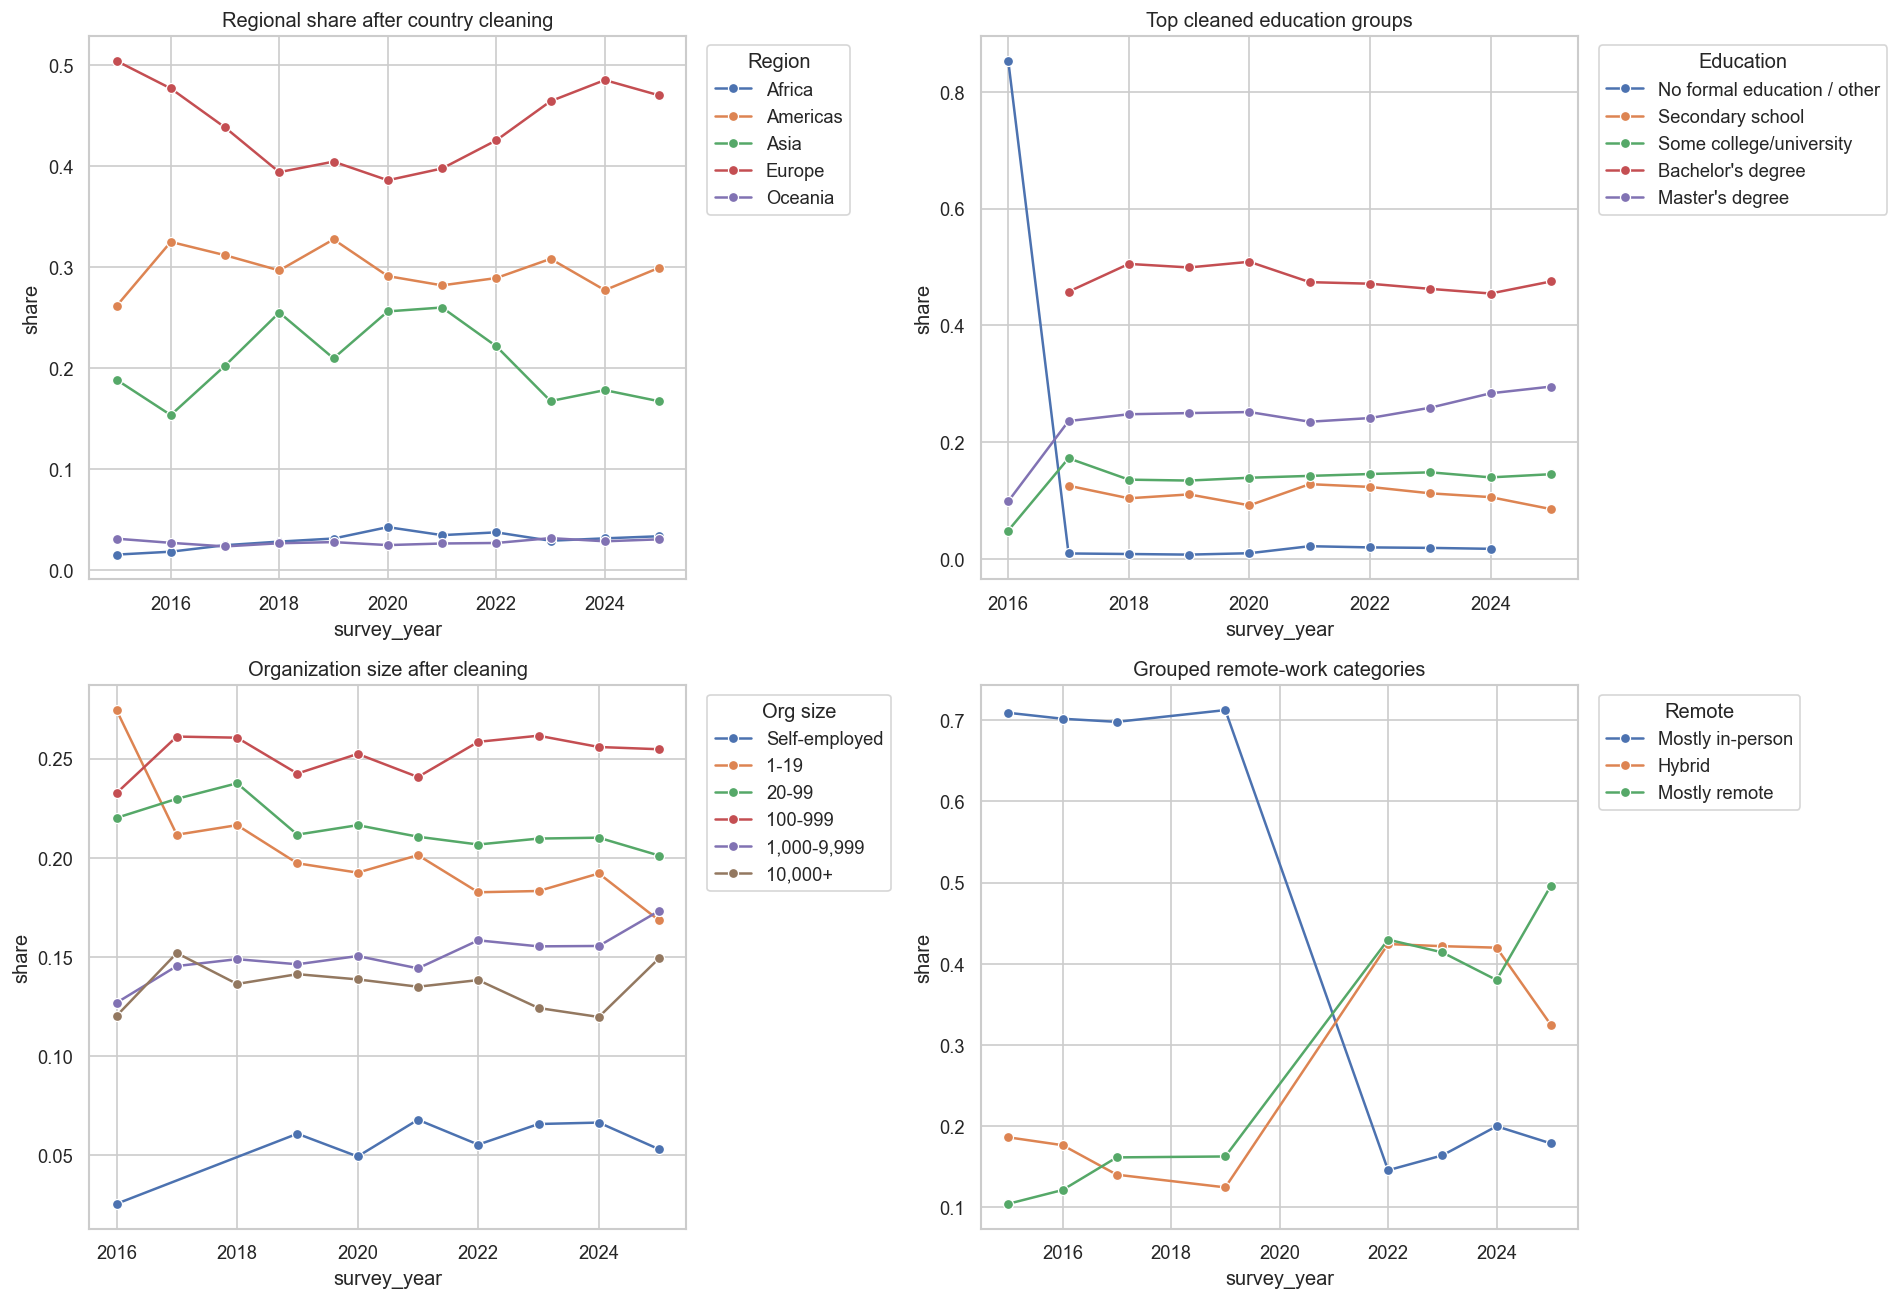

In [ ]:
COUNTRY_SPECIAL = {'Nomadic', 'Other Country (Not Listed Above)', 'I prefer not to say', 'Other (please specify)'}

COUNTRY_ALIAS = {
    'Venezuela, Bolivarian Republic of...': 'Venezuela',
    'Iran, Islamic Republic of...': 'Iran',
    'Viet Nam': 'Vietnam',
    'Republic of Korea': 'South Korea',
    'Korea South': 'South Korea',
    "Democratic People's Republic of Korea": 'North Korea',
    'Korea North': 'North Korea',
    'Hong Kong (S.A.R.)': 'Hong Kong',
    'Republic of Moldova': 'Moldova',
    'Moldavia': 'Moldova',
    'Bosnia Herzegovina': 'Bosnia and Herzegovina',
    'Bosnia-Herzegovina': 'Bosnia and Herzegovina',
    'The former Yugoslav Republic of Macedonia': 'North Macedonia',
    'Republic of North Macedonia': 'North Macedonia',
    'Macedonia': 'North Macedonia',
    "Lao People's Democratic Republic": 'Laos',
    'Syrian Arab Republic': 'Syria',
    'United Republic of Tanzania': 'Tanzania',
    'Libyan Arab Jamahiriya': 'Libya',
    'Myanmar, {Burma}': 'Myanmar',
    'Ireland {Republic}': 'Ireland',
    'Azerbaidjan': 'Azerbaijan',
    'Antigua & Deps': 'Antigua and Barbuda',
    'Trinidad & Tobago': 'Trinidad and Tobago',
    'Micronesia, Federated States of...': 'Micronesia',
    'Virgin Islands (USA)': 'United States Virgin Islands',
    'Reunion (French)': 'Reunion',
    'New Caledonia (French)': 'New Caledonia'
}

REGION_ALLOWED = {'Africa', 'Americas', 'Asia', 'Europe', 'Oceania'}

EDUCATION_ORDER = ['No formal education / other', 'Primary/elementary school', 'Secondary school', 'Some college/university', 'Associate degree', "Bachelor's degree", "Master's degree", 'Professional degree', 'Doctoral degree']
ORG_SIZE_ORDER = ['Self-employed', '1-19', '20-99', '100-999', '1,000-9,999', '10,000+']
REMOTE_ORDER = ['Mostly in-person', 'Hybrid', 'Mostly remote']

cc = coco.CountryConverter()


def convert_one_country(name, target):
    value = cc.convert(names=name, to=target, not_found=None)
    if isinstance(value, (list, tuple, np.ndarray)):
        value = value[0] if len(value) else pd.NA
    if value in {'not found', 'not found in regex', '', 'Other'}:
        return pd.NA
    return value


def build_country_lookup(series):
    lookup = pd.DataFrame({'country': sorted(series.dropna().astype(str).str.strip().unique())})
    lookup['country_input'] = lookup['country'].replace(COUNTRY_ALIAS)
    lookup.loc[lookup['country'].isin(COUNTRY_SPECIAL), 'country_input'] = pd.NA

    lookup['country_clean'] = pd.NA
    lookup['region'] = pd.NA

    valid = lookup['country_input'].notna()
    lookup.loc[valid, 'country_clean'] = lookup.loc[valid, 'country_input'].map(lambda name: convert_one_country(name, 'name_short'))
    lookup.loc[valid, 'region'] = lookup.loc[valid, 'country_input'].map(lambda name: convert_one_country(name, 'continent'))

    lookup['country_clean'] = lookup['country_clean'].replace(['not found', 'not found in regex', '', 'Other'], pd.NA)
    lookup['region'] = lookup['region'].replace({'America': 'Americas', 'Antarctica': pd.NA, 'not found': pd.NA, 'not found in regex': pd.NA, '': pd.NA, 'Other': pd.NA})
    lookup['region'] = lookup['region'].where(lookup['region'].isin(REGION_ALLOWED), pd.NA)
    return lookup[['country', 'country_clean', 'region']]


def clean_education(value):
    if pd.isna(value):
        return pd.NA
    text = re.sub(r'\s*\([^)]*\)', '', str(value).strip())
    lower = re.sub(r'master.?s', "master's", re.sub(r'bachelor.?s', "bachelor's", text.lower()))
    if 'prefer not' in lower:
        return pd.NA
    if 'never completed any formal education' in lower or 'self-taught' in lower or 'something else' in lower or 'no formal' in lower:
        return 'No formal education / other'
    if 'primary' in lower or 'elementary' in lower:
        return 'Primary/elementary school'
    if 'secondary school' in lower:
        return 'Secondary school'
    if 'some college' in lower or 'some university' in lower:
        return 'Some college/university'
    if 'associate degree' in lower:
        return 'Associate degree'
    if 'bachelor' in lower:
        return "Bachelor's degree"
    if 'master' in lower:
        return "Master's degree"
    if 'professional degree' in lower:
        return 'Professional degree'
    if 'doctoral degree' in lower or 'ph.d' in lower or 'ed.d' in lower:
        return 'Doctoral degree'
    return 'Other / ungrouped'


def clean_org_size(value):
    if pd.isna(value):
        return pd.NA
    lower = str(value).strip().lower()
    if any(term in lower for term in ["don't know", 'don?t know', 'not sure', 'prefer not']):
        return pd.NA
    if 'just me' in lower or 'not part of a company' in lower:
        return 'Self-employed'
    if any(term in lower for term in ['1-4 employees', '2 to 9 employees', '2-9 employees', '5-9 employees', 'fewer than 10 employees', '10 to 19 employees', '10-19 employees', 'less than 20 employees']):
        return '1-19'
    if '20 to 99 employees' in lower or '20-99 employees' in lower:
        return '20-99'
    if any(term in lower for term in ['100 to 499 employees', '100-499 employees', '500 to 999 employees', '500-999 employees']):
        return '100-999'
    if any(term in lower for term in ['1,000 to 4,999 employees', '1,000-4,999 employees', '5,000 to 9,999 employees', '5,000-9,999 employees']):
        return '1,000-9,999'
    if '10,000 or more employees' in lower or '10,000+ employees' in lower:
        return '10,000+'
    return pd.NA


def group_remote(value):
    if pd.isna(value):
        return pd.NA
    mostly_in_person = {'In-person', 'Full in-person', 'Never', 'Less than once per month / Never', 'I rarely work remote', 'I rarely work remotely', 'A few days each month'}
    hybrid = {'Less than half the time, but at least one day each week', 'About half the time', 'Part-time remote', 'Part-time Remote', 'Hybrid (some remote, leans heavy to in-person)', 'Hybrid (some remote, some in-person)', 'Your choice (very flexible, you can come in when you want or just as needed)'}
    mostly_remote = {'More than half, but not all, the time', 'Hybrid (some in-person, leans heavy to flexibility)', 'Fully remote', 'Full-time remote', 'Full-time Remote', "All or almost all the time (I'm full-time remote)", 'Remote'}
    if value in mostly_in_person:
        return 'Mostly in-person'
    if value in hybrid:
        return 'Hybrid'
    if value in mostly_remote:
        return 'Mostly remote'
    return pd.NA


def top_share(frame, column, top_n=5, order=None):
    counts = frame.dropna(subset=[column]).groupby(['survey_year', column]).size().rename('count').reset_index()
    top_values = counts[column].drop_duplicates().tolist() if top_n is None else counts.groupby(column)['count'].sum().nlargest(top_n).index.tolist()
    if order is not None:
        rank = {value: i for i, value in enumerate(order)}
        top_values = sorted(top_values, key=lambda value: rank.get(value, len(rank)))
    counts = counts.loc[counts[column].isin(top_values)].copy()
    counts['share'] = counts['count'] / counts.groupby('survey_year')['count'].transform('sum')
    return counts, top_values


country_lookup = build_country_lookup(clean['country'])
clean = clean.drop(columns=['country_clean', 'region'], errors='ignore').merge(country_lookup, on='country', how='left')
clean['education_clean'] = clean['education'].map(clean_education)
clean['org_size_clean'] = clean['org_size'].map(clean_org_size)
clean['remote_group'] = clean['remote'].map(group_remote)

region_quality = clean.groupby('survey_year').agg(country_clean_share=('country_clean', lambda s: s.notna().mean()), region_share=('region', lambda s: s.notna().mean()))
display(region_quality.round(3))
print("Countries still missing a region mapping")
display(clean.loc[clean['country_clean'].notna() & clean['region'].isna(), 'country_clean'].value_counts().head(20))

display(pd.DataFrame({'field': ['education', 'org_size', 'remote'], 'raw_levels': [clean['education'].dropna().nunique(), clean['org_size'].dropna().nunique(), clean['remote'].dropna().nunique()], 'clean_levels': [clean['education_clean'].dropna().nunique(), clean['org_size_clean'].dropna().nunique(), clean['remote_group'].dropna().nunique()]}))

region_counts = clean.dropna(subset=['region']).groupby(['survey_year', 'region']).size().rename('count').reset_index()
region_counts['share'] = region_counts['count'] / region_counts.groupby('survey_year')['count'].transform('sum')
education_share, education_order = top_share(clean, 'education_clean', top_n=5, order=EDUCATION_ORDER)
org_share, org_order = top_share(clean, 'org_size_clean', top_n=None, order=ORG_SIZE_ORDER)
remote_share, remote_order = top_share(clean, 'remote_group', top_n=None, order=REMOTE_ORDER)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
sns.lineplot(data=region_counts, x='survey_year', y='share', hue='region', marker='o', ax=axes[0, 0])
axes[0, 0].set_title("Regional share after country cleaning")
axes[0, 0].legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left')
sns.lineplot(data=education_share, x='survey_year', y='share', hue='education_clean', hue_order=education_order, marker='o', ax=axes[0, 1])
axes[0, 1].set_title("Top cleaned education groups")
axes[0, 1].legend(title='Education', bbox_to_anchor=(1.02, 1), loc='upper left')
sns.lineplot(data=org_share, x='survey_year', y='share', hue='org_size_clean', hue_order=org_order, marker='o', ax=axes[1, 0])
axes[1, 0].set_title("Organization size after cleaning")
axes[1, 0].legend(title='Org size', bbox_to_anchor=(1.02, 1), loc='upper left')
sns.lineplot(data=remote_share, x='survey_year', y='share', hue='remote_group', hue_order=remote_order, marker='o', ax=axes[1, 1])
axes[1, 1].set_title("Grouped remote-work categories")
axes[1, 1].legend(title='Remote', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Numeric Cleanup and Compensation Sample

This pass removes obviously bad numeric values, builds a cross-year professional-experience field, and defines the first compensation analysis window.

,age_available,pro_exp_available,valid_comp_share,comp_sample_share
survey_year,,,,
2015,0.977,0.000,0.570,0.517
2016,0.988,0.884,0.745,0.653
2017,0.000,0.728,0.245,0.245
2018,0.653,0.782,0.467,0.420
2019,0.890,0.825,0.609,0.551
2020,0.705,0.712,0.527,0.479
2021,0.981,0.726,0.551,0.503
2022,0.961,0.737,0.503,0.463
2023,0.995,0.765,0.530,0.490


C:\Users\davis\AppData\Local\Temp\ipykernel_26872\3375717255.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  "years_code_pro_gt_years_code": clean.groupby("survey_year").apply(lambda frame: ((frame["years_code_pro_num"] > frame["years_code_num"]) & frame["years_code_num"].notna() & frame["years_code_pro_num"].notna()).sum()),
C:\Users\davis\AppData\Local\Temp\ipykernel_26872\3375717255.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns afte

,years_code_gt_50,years_code_pro_gt_years_code,work_exp_gt_50,comp_outside_range
survey_year,,,,
2015,0,0,0,0
2016,0,0,0,0
2017,0,457,0,318
2018,0,629,0,1563
2019,0,969,0,1689
2020,0,476,0,760
2021,0,647,0,831
2022,0,536,0,1202
2023,0,682,0,744


Feature coverage inside the 2019+ compensation sample


country_clean                    99.9
region                           99.9
age_mid                          97.6
education_clean                  99.5
org_size_clean                   97.7
remote_group                     67.9
professional_experience_years    99.1
dev_type                         99.7
Name: non_null_pct, dtype: float64

,survey_year,region,n,median_comp
0,2019,Africa,1124,13512.0
1,2019,Americas,17299,90000.0
2,2019,Asia,7815,14484.0
3,2019,Europe,21247,50184.0
4,2019,Oceania,1427,76156.0
5,2020,Africa,786,14142.0
6,2020,Americas,10284,90000.0
7,2020,Asia,5371,14256.0
8,2020,Europe,13576,50806.0
9,2020,Oceania,873,73491.0


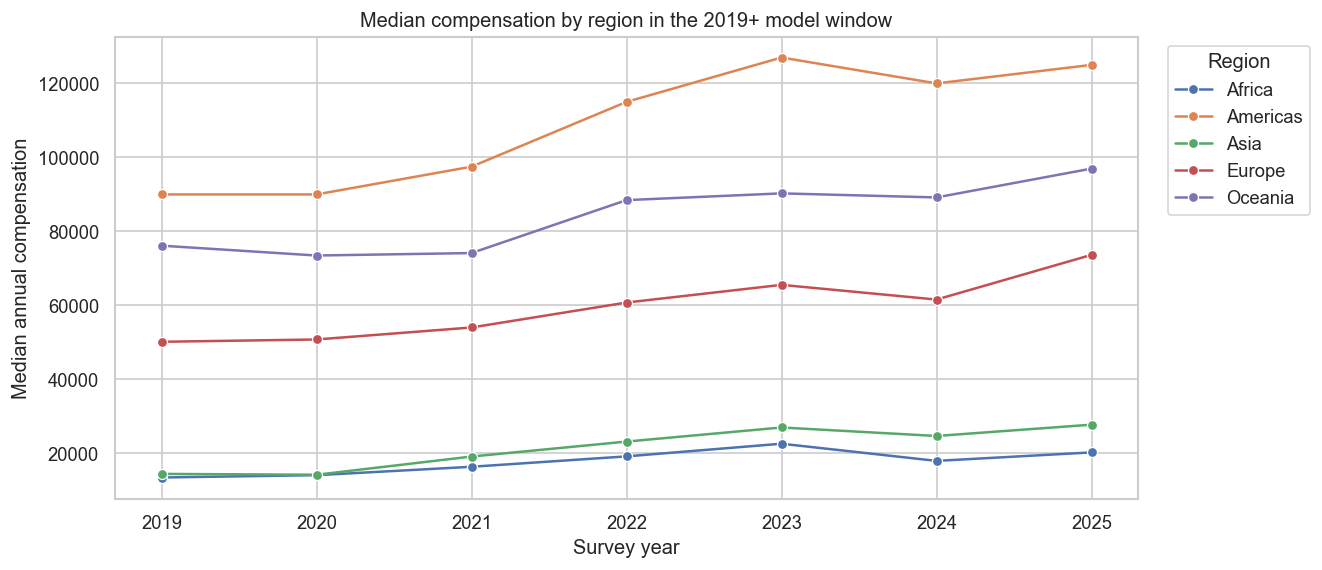

In [13]:
clean['age_mid'] = clean['age_num'].where(clean['age_num'].between(10, 90))
clean['years_code_clean'] = clean['years_code_num'].where(clean['years_code_num'].between(0, 50))
clean['years_code_pro_clean'] = clean['years_code_pro_num'].where(clean['years_code_pro_num'].between(0, 50))
clean['work_exp_clean'] = clean['work_exp_num'].where(clean['work_exp_num'].between(0, 50))
clean.loc[(clean['years_code_pro_clean'] > clean['years_code_clean']) & clean['years_code_clean'].notna(), 'years_code_pro_clean'] = np.nan
clean['professional_experience_years'] = clean['years_code_pro_clean'].combine_first(clean['work_exp_clean'])
clean['comp_usd_clean'] = clean['comp_usd'].where(clean['comp_usd'].between(1000, 1_000_000))
clean['age_group'] = pd.cut(clean['age_mid'], bins=[10, 25, 35, 45, 55, 100], labels=['Under 25', '25-34', '35-44', '45-54', '55+'], right=False)
clean['experience_bin'] = pd.cut(clean['professional_experience_years'], bins=[0, 2, 5, 10, 20, 60], labels=['0-2', '3-5', '6-10', '11-20', '21+'], include_lowest=True)
clean['is_comp_analysis_sample'] = clean['is_professional'] & clean['comp_usd_clean'].notna()
clean['is_comp_model_sample'] = clean['is_modern_window'] & clean['is_comp_analysis_sample']

display(clean.groupby('survey_year').agg(age_available=('age_mid', lambda s: s.notna().mean()), pro_exp_available=('professional_experience_years', lambda s: s.notna().mean()), valid_comp_share=('comp_usd_clean', lambda s: s.notna().mean()), comp_sample_share=('is_comp_analysis_sample', 'mean')).round(3))

display(pd.DataFrame({'years_code_gt_50': clean.groupby('survey_year')['years_code_num'].apply(lambda s: (s > 50).sum()), 'years_code_pro_gt_years_code': clean.groupby('survey_year').apply(lambda frame: ((frame['years_code_pro_num'] > frame['years_code_num']) & frame['years_code_num'].notna() & frame['years_code_pro_num'].notna()).sum()), 'work_exp_gt_50': clean.groupby('survey_year')['work_exp_num'].apply(lambda s: (s > 50).sum()), 'comp_outside_range': clean.groupby('survey_year').apply(lambda frame: (frame['comp_usd'].notna() & ~frame['comp_usd'].between(1000, 1_000_000)).sum())}))

print("Feature coverage inside the 2019+ compensation sample")
feature_cols = ['country_clean', 'region', 'age_mid', 'education_clean', 'org_size_clean', 'remote_group', 'professional_experience_years', 'dev_type']
display((clean.loc[clean['is_comp_model_sample'], feature_cols].notna().mean() * 100).round(1).rename('non_null_pct'))

comp_region = clean.loc[clean['is_comp_model_sample']].groupby(['survey_year', 'region']).agg(n=('row_id', 'size'), median_comp=('comp_usd_clean', 'median')).reset_index()
comp_region = comp_region.loc[comp_region['n'] >= 300]
display(comp_region.head(15))

plt.figure(figsize=(11, 5))
sns.lineplot(data=comp_region, x='survey_year', y='median_comp', hue='region', marker='o')
plt.title("Median compensation by region in the 2019+ model window")
plt.xlabel("Survey year")
plt.ylabel("Median annual compensation")
plt.legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()


## Role Families and Final Clean Table

`DevType` stays multi-select, so this notebook keeps a long role table and adds simple respondent-level role flags for later subgroup work and modeling.

,country_clean,region,age_mid,education_clean,org_size_clean,remote_group,professional_experience_years,comp_usd_clean
survey_year,,,,,,,,
2015,96.9,96.9,97.7,0.0,0.0,61.9,0.0,57.0
2016,99.1,99.1,98.8,80.2,69.9,71.6,88.4,74.5
2017,99.7,99.7,0.0,97.8,72.7,82.0,72.8,24.5
2018,99.5,99.5,65.3,95.8,72.4,0.0,78.2,46.7
2019,99.7,99.7,89.0,97.2,80.8,74.9,82.5,60.9
2020,99.3,99.3,70.5,89.1,68.8,0.0,71.2,52.7
2021,99.9,99.9,98.1,99.6,71.2,0.0,72.6,55.1
2022,97.9,97.9,96.1,97.7,68.3,80.5,73.7,50.3
2023,98.6,98.6,99.5,98.6,71.5,82.8,76.5,53.0


(746226, 45)


,row_id,survey_year,response_id,country,country_clean,region,age,age_mid,age_group,gender,main_branch,student,employment,employment_group,is_employed,is_professional,education,education_clean,org_size,org_size_clean,dev_type,industry,remote,remote_group,years_code,years_code_clean,years_code_pro,work_exp,professional_experience_years,comp,comp_usd_clean,is_comp_analysis_sample,is_comp_model_sample,role_family_count,role_back_end,role_data_ml,role_desktop_enterprise,role_devops_cloud,role_front_end,role_full_stack,role_management,role_mobile,role_other,role_qa_testing,role_student_academic
660422,2024028824,2024,28825,Thailand,Thailand,Asia,25-34 years old,29.5,25-34,NaN,I am a developer by profession,NaN,"Employed, full-time",Employed full-time,True,True,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Bachelor's degree,10 to 19 employees,1-19,"Developer, full-stack",NaN,In-person,Mostly in-person,8,8.0,1,NaN,1.0,NaN,NaN,False,False,1,0,0,0,0,0,1,0,0,0,0,0
115194,2017033078,2017,33079,New Zealand,New Zealand,Oceania,NaN,NaN,NaN,NaN,NaN,NaN,"Not employed, and not looking for work",Not employed,False,False,Secondary school,Secondary school,NaN,<NA>,NaN,NaN,NaN,<NA>,2 to 3 years,2.5,NaN,NaN,NaN,NaN,NaN,False,False,0,0,0,0,0,0,0,0,0,0,0,0
462718,2021077011,2021,77012,Denmark,Denmark,Europe,35-44 years old,39.5,35-44,Man,I am a developer by profession,NaN,Employed full-time,Employed full-time,True,True,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Master's degree,20 to 99 employees,20-99,"Developer, desktop or enterprise applications;...",NaN,NaN,<NA>,30,30.0,20,NaN,20.0,118104.0,118104.0,True,True,2,1,0,1,0,0,0,0,0,0,0,0
683102,2024051504,2024,51505,United States of America,United States,Americas,25-34 years old,29.5,25-34,NaN,I am a developer by profession,NaN,"Employed, full-time",Employed full-time,True,True,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Bachelor's degree,"5,000 to 9,999 employees","1,000-9,999","Developer, back-end",Software Development,"Hybrid (some remote, some in-person)",Hybrid,14,14.0,6,6.0,6.0,NaN,NaN,False,False,1,1,0,0,0,0,0,0,0,0,0,0
116754,2017034638,2017,34639,United States,United States,Americas,NaN,NaN,NaN,NaN,NaN,NaN,Employed full-time,Employed full-time,True,True,Bachelor's degree,Bachelor's degree,100 to 499 employees,100-999,Web developer,NaN,All or almost all the time (I'm full-time remote),Mostly remote,14 to 15 years,14.5,8 to 9 years,NaN,8.5,NaN,NaN,False,False,1,0,0,0,0,0,0,0,0,1,0,0


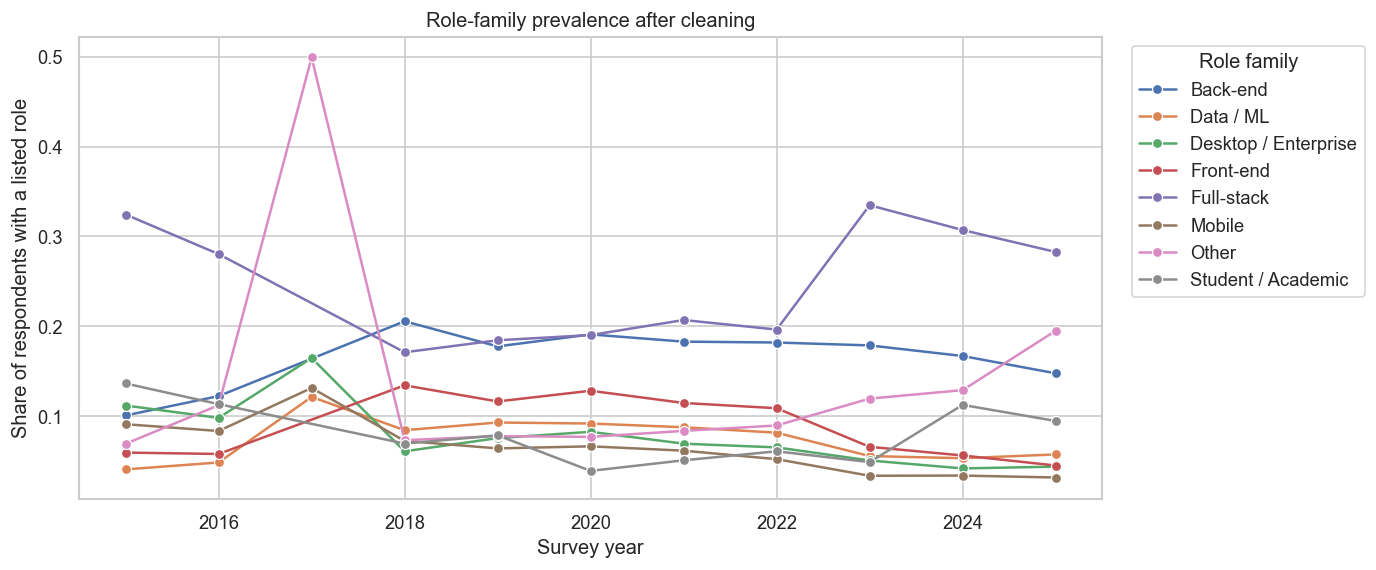

In [14]:
def role_family(token):
    if pd.isna(token):
        return pd.NA
    t = str(token).strip().lower()
    if 'full-stack' in t:
        return 'Full-stack'
    if 'back-end' in t or 'backend' in t or 'server' in t:
        return 'Back-end'
    if 'front-end' in t or 'frontend' in t:
        return 'Front-end'
    if 'data' in t or 'machine learning' in t or 'scientist' in t or 'analyst' in t:
        return 'Data / ML'
    if 'mobile' in t or 'ios' in t or 'android' in t:
        return 'Mobile'
    if 'devops' in t or 'site reliability' in t or 'cloud' in t or 'system administrator' in t:
        return 'DevOps / Cloud'
    if 'desktop' in t or 'enterprise' in t:
        return 'Desktop / Enterprise'
    if 'manager' in t or 'executive' in t:
        return 'Management'
    if 'student' in t or 'academic researcher' in t or 'educator' in t:
        return 'Student / Academic'
    if 'qa' in t or 'quality assurance' in t or 'test' in t:
        return 'QA / Testing'
    return 'Other'


roles_long = clean.loc[clean['dev_type'].notna(), ['row_id', 'survey_year', 'dev_type']].copy()
roles_long['dev_type'] = roles_long['dev_type'].astype(str).str.split(';')
roles_long = roles_long.explode('dev_type')
roles_long['dev_type'] = roles_long['dev_type'].str.strip()
roles_long = roles_long.loc[roles_long['dev_type'].ne('')].copy()
roles_long['role_family'] = roles_long['dev_type'].map(role_family)

role_flags = pd.crosstab(roles_long['row_id'], roles_long['role_family']).clip(upper=1)
role_flags.columns = ['role_' + re.sub(r'[^a-z0-9]+', '_', col.lower()).strip('_') for col in role_flags.columns]
clean = clean.merge(role_flags.reset_index(), on='row_id', how='left')
role_cols = sorted([col for col in clean.columns if col.startswith('role_')])
clean[role_cols] = clean[role_cols].fillna(0).astype(int)
clean['role_family_count'] = clean[role_cols].sum(axis=1)

clean_cols = ['row_id', 'survey_year', 'response_id', 'country', 'country_clean', 'region', 'age', 'age_mid', 'age_group', 'gender', 'main_branch', 'student', 'employment', 'employment_group', 'is_employed', 'is_professional', 'education', 'education_clean', 'org_size', 'org_size_clean', 'dev_type', 'industry', 'remote', 'remote_group', 'years_code', 'years_code_clean', 'years_code_pro', 'work_exp', 'professional_experience_years', 'comp', 'comp_usd_clean', 'is_comp_analysis_sample', 'is_comp_model_sample', 'role_family_count'] + role_cols
clean_core = clean[clean_cols].copy()

coverage_cols = ['country_clean', 'region', 'age_mid', 'education_clean', 'org_size_clean', 'remote_group', 'professional_experience_years', 'comp_usd_clean']
display((clean_core.groupby('survey_year')[coverage_cols].apply(lambda frame: frame.notna().mean()) * 100).round(1))
print(clean_core.shape)
display(clean_core.sample(5, random_state=42))

role_prev = roles_long.groupby(['survey_year', 'role_family'])['row_id'].nunique().rename('respondents').reset_index()
role_prev['share'] = role_prev['respondents'] / role_prev.groupby('survey_year')['respondents'].transform('sum')
top_roles = role_prev.groupby('role_family')['respondents'].sum().nlargest(8).index
role_prev = role_prev.loc[role_prev['role_family'].isin(top_roles)]

plt.figure(figsize=(11, 5))
sns.lineplot(data=role_prev, x='survey_year', y='share', hue='role_family', marker='o')
plt.title("Role-family prevalence after cleaning")
plt.xlabel("Survey year")
plt.ylabel("Share of respondents with a listed role")
plt.legend(title='Role family', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()


## Next Steps

This gets us to a usable cleaning baseline. The next `.py` work should focus on stricter country QA, deciding the final compensation-model cohort, and adding inflation adjustment if we want real cross-year compensation comparisons.